# Data Understanding: Jalur Irisan 3 Kelas
### Eksplorasi Komparatif Dataset HAM10000, ISIC 2017, dan ISIC 2019

Notebook ini bertujuan untuk mengaudit dan memahami karakteristik data mentah sebelum tahap persiapan data (preprocessing):
1. Memeriksa format metadata dan sebaran diagnosis asli pada masing-masing dataset sumber.
2. Menganalisis relasi foto dengan lesi unik pasien pada HAM10000 untuk mencegah kebocoran data.
3. Mendeteksi citra kembar (duplikat) lintas-dataset.
4. Menerapkan dasar ontologi medis untuk menyatukan label seborrheic keratosis ke dalam kelompok payung BKL.
5. Menentukan irisan 3 kelas medis bersama (NV, MEL, BKL) dan memeriksa resolusi fisik citra.

## Langkah 1: Setup Library dan Konfigurasi Lokasi Dataset
Menyiapkan pustaka Python yang dibutuhkan, mendeteksi lokasi folder dataset, dan mendefinisikan palet warna untuk 3 kelas target.

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 110

COLOR_NV  = '#3498db'
COLOR_MEL = '#e74c3c'
COLOR_BKL = '#f39c12'
PALETTE_3K = {'NV': COLOR_NV, 'MEL': COLOR_MEL, 'BKL': COLOR_BKL}

current_dir = os.getcwd()
candidates = [
    os.path.join(current_dir, 'Dataset'),
    os.path.join(os.path.dirname(current_dir), 'Dataset'),
    os.path.join(os.path.dirname(os.path.dirname(current_dir)), 'Dataset'),
    r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"
]

DATASET_DIR = None
for cand in candidates:
    if os.path.exists(cand):
        DATASET_DIR = cand
        break

if DATASET_DIR is None:
    raise FileNotFoundError("Folder Dataset tidak ditemukan!")

print(f"Folder Dataset terdeteksi: {DATASET_DIR}")

Folder Dataset terdeteksi: c:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset


## Langkah 2: Eksplorasi Karakteristik Dataset ISIC 2017
Memeriksa file ground truth ISIC 2017 pada partisi Training, Validation, dan Test dengan total 2.750 citra serta 3 diagnosis bawaannya.

In [2]:
path_17_train = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv')
path_17_val   = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv')
path_17_test  = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv')

df_17_train_raw = pd.read_csv(path_17_train)
df_17_val_raw   = pd.read_csv(path_17_val)
df_17_test_raw  = pd.read_csv(path_17_test)

def parse_isic_2017(df, split_name):
    id_col = 'image_id' if 'image_id' in df.columns else df.columns[0]
    records = []
    for _, row in df.iterrows():
        img_id = str(row[id_col]).replace('.jpg', '')
        if row.get('melanoma') == 1.0:
            diag = 'melanoma'
        elif row.get('seborrheic_keratosis') == 1.0:
            diag = 'seborrheic_keratosis'
        else:
            diag = 'nevus'
        records.append({'image_id': img_id, 'split': split_name, 'label_asli': diag})
    return pd.DataFrame(records)

df_17_all = pd.concat([
    parse_isic_2017(df_17_train_raw, 'Train'),
    parse_isic_2017(df_17_val_raw, 'Val'),
    parse_isic_2017(df_17_test_raw, 'Test')
], ignore_index=True)

print("Contoh 5 baris file ground truth ISIC 2017 (Train):")
display(df_17_train_raw.head())

print("\nJumlah data per split di ISIC 2017:")
crosstab_17 = pd.crosstab(df_17_all['label_asli'], df_17_all['split'], margins=True, margins_name='Total')
crosstab_17 = crosstab_17[['Train', 'Val', 'Test', 'Total']]
display(crosstab_17)

Contoh 5 baris file ground truth ISIC 2017 (Train):


,image_id,melanoma,seborrheic_keratosis
0,ISIC_0000000,0.0,0.0
1,ISIC_0000001,0.0,0.0
2,ISIC_0000002,1.0,0.0
3,ISIC_0000003,0.0,0.0
4,ISIC_0000004,1.0,0.0



Jumlah data per split di ISIC 2017:


split,Train,Val,Test,Total
label_asli,,,,
melanoma,374,30,117,521
nevus,1372,78,393,1843
seborrheic_keratosis,254,42,90,386
Total,2000,150,600,2750


## Langkah 3: Eksplorasi Karakteristik Dataset HAM10000
Memeriksa metadata HAM10000 yang memuat 10.015 citra dengan 7 kelas diagnosis asli pada kolom dx.

In [3]:
path_ham_meta = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_metadata')
df_ham = pd.read_csv(path_ham_meta)

print(f"Total baris HAM10000: {len(df_ham):,} citra")
print("Contoh 5 baris metadata HAM10000:")
display(df_ham.head())

ham_counts = df_ham['dx'].value_counts()
ham_pcts = (df_ham['dx'].value_counts(normalize=True) * 100).round(2)
df_ham_dx = pd.DataFrame({
    'Kode dx': ham_counts.index,
    'Jumlah Gambar': ham_counts.values,
    'Persen (%)': ham_pcts.values
})

nama_medis = {
    'nv': 'Melanocytic Nevus (Tahi Lalat)',
    'mel': 'Melanoma (Kanker Ganas)',
    'bkl': 'Benign Keratosis (Keratosis Jinak)',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'vasc': 'Vascular Lesion',
    'df': 'Dermatofibroma'
}
df_ham_dx['Nama Penyakit'] = df_ham_dx['Kode dx'].map(nama_medis)

print("\nDistribusi 7 kelas di HAM10000:")
display(df_ham_dx)

Total baris HAM10000: 10,015 citra
Contoh 5 baris metadata HAM10000:


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern



Distribusi 7 kelas di HAM10000:


,Kode dx,Jumlah Gambar,Persen (%),Nama Penyakit
0,nv,6705,66.95,Melanocytic Nevus (Tahi Lalat)
1,mel,1113,11.11,Melanoma (Kanker Ganas)
2,bkl,1099,10.97,Benign Keratosis (Keratosis Jinak)
3,bcc,514,5.13,Basal Cell Carcinoma
4,akiec,327,3.27,Actinic Keratosis
5,vasc,142,1.42,Vascular Lesion
6,df,115,1.15,Dermatofibroma


## Langkah 4: Analisis Relasi Lesi Pasien pada HAM10000
Menganalisis kolom lesion_id untuk mengidentifikasi citra yang berasal dari lesi pasien yang sama guna mencegah risiko kebocoran data saat pembagian dataset.

In [4]:
total_images = len(df_ham)
unique_lesions = df_ham['lesion_id'].nunique()
multi_images = total_images - unique_lesions

print(f"Total foto di HAM10000   : {total_images:,} foto")
print(f"Total lesi unik pasien   : {unique_lesions:,} lesi")
print(f"Foto tambahan (multi-sudut): {multi_images:,} foto ({multi_images/total_images*100:.1f}%)")

top_lesion = df_ham['lesion_id'].value_counts().index[0]
print(f"\nContoh lesi dengan foto terbanyak ({top_lesion}):")
display(df_ham[df_ham['lesion_id'] == top_lesion][['lesion_id', 'image_id', 'dx', 'dx_type', 'localization']])

Total foto di HAM10000   : 10,015 foto
Total lesi unik pasien   : 7,470 lesi
Foto tambahan (multi-sudut): 2,545 foto (25.4%)

Contoh lesi dengan foto terbanyak (HAM_0003789):


,lesion_id,image_id,dx,dx_type,localization
805,HAM_0003789,ISIC_0026016,bkl,confocal,face
806,HAM_0003789,ISIC_0029505,bkl,confocal,face
817,HAM_0003789,ISIC_0031277,bkl,confocal,face
819,HAM_0003789,ISIC_0031853,bkl,confocal,face
867,HAM_0003789,ISIC_0029464,bkl,confocal,face
869,HAM_0003789,ISIC_0024915,bkl,confocal,face


## Langkah 5: Eksplorasi Karakteristik Dataset ISIC 2019
Memeriksa file ground truth ISIC 2019 Training yang memiliki 25.331 baris dengan 10 kolom format one-hot (8 kelas target diagnosis dan 1 kolom UNK).

In [5]:
path_19_gt = os.path.join(DATASET_DIR, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv')
df_19_gt = pd.read_csv(path_19_gt)

print(f"Total baris ISIC 2019: {len(df_19_gt):,} citra")
print(f"Daftar 10 kolom asli : {df_19_gt.columns.tolist()}")
print("\nContoh 5 baris pertama:")
display(df_19_gt.head())

diag_cols_19 = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
records_19 = []
for col in diag_cols_19:
    jml = int(df_19_gt[col].sum())
    prop = round((jml / len(df_19_gt)) * 100, 2)
    records_19.append({'Kolom': col, 'Jumlah Gambar': jml, 'Persen (%)': prop})

df_19_summary = pd.DataFrame(records_19)
arti_kolom = {
    'MEL': 'Melanoma',
    'NV': 'Melanocytic Nevus (Tahi Lalat)',
    'BCC': 'Basal Cell Carcinoma',
    'AK': 'Actinic Keratosis',
    'BKL': 'Benign Keratosis',
    'DF': 'Dermatofibroma',
    'VASC': 'Vascular Lesion',
    'SCC': 'Squamous Cell Carcinoma',
    'UNK': 'Unknown (Out of Distribution)'
}
df_19_summary['Keterangan'] = df_19_summary['Kolom'].map(arti_kolom)
df_19_summary = df_19_summary.sort_values(by='Jumlah Gambar', ascending=False).reset_index(drop=True)

print("\nJumlah data per kolom ISIC 2019:")
display(df_19_summary)

row_sums = df_19_gt[diag_cols_19].sum(axis=1)
print(f"\nValidasi baris valid (tepat 1 kelas): {(row_sums == 1).sum():,} dari {len(df_19_gt):,} baris.")
print(f"Baris tanpa label: {(row_sums != 1).sum()} baris.")

Total baris ISIC 2019: 25,331 citra
Daftar 10 kolom asli : ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']

Contoh 5 baris pertama:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Jumlah data per kolom ISIC 2019:


,Kolom,Jumlah Gambar,Persen (%),Keterangan
0,NV,12875,50.83,Melanocytic Nevus (Tahi Lalat)
1,MEL,4522,17.85,Melanoma
2,BCC,3323,13.12,Basal Cell Carcinoma
3,BKL,2624,10.36,Benign Keratosis
4,AK,867,3.42,Actinic Keratosis
5,SCC,628,2.48,Squamous Cell Carcinoma
6,VASC,253,1.00,Vascular Lesion
7,DF,239,0.94,Dermatofibroma
8,UNK,0,0.00,Unknown (Out of Distribution)



Validasi baris valid (tepat 1 kelas): 25,331 dari 25,331 baris.
Baris tanpa label: 0 baris.


## Langkah 6: Deteksi dan Analisis Gambar Duplikat Antar-Dataset
Melacak citra kembar yang digunakan berulang antar-dataset untuk memastikan dataset benchmark HAM10000 dipertahankan secara utuh.

In [6]:
ids_ham = set(df_ham['image_id'])
ids_19  = set(df_19_gt['image'])
ids_17  = set(df_17_all['image_id'])

overlap_ham_19 = ids_ham.intersection(ids_19)
overlap_17_all = ids_17.intersection(ids_ham.union(ids_19))

df_overlap_summary = pd.DataFrame([
    {
        'Source Dataset': 'HAM10000',
        'Total Mentah': f"{len(ids_ham):,}",
        'Duplikat Dibuang': "0",
        'Duplikat dengan Dataset Mana': "- (Data primer utuh)",
        'Citra Dipertahankan': f"{len(ids_ham):,}",
        'Persentase Bertahan': "100.0%"
    },
    {
        'Source Dataset': 'ISIC 2019 (Train)',
        'Total Mentah': f"{len(ids_19):,}",
        'Duplikat Dibuang': f"{len(overlap_ham_19):,}",
        'Duplikat dengan Dataset Mana': f"HAM10000 ({len(overlap_ham_19):,})",
        'Citra Dipertahankan': f"{len(ids_19) - len(overlap_ham_19):,}",
        'Persentase Bertahan': f"{(len(ids_19) - len(overlap_ham_19)) / len(ids_19) * 100:.1f}%"
    },
    {
        'Source Dataset': 'ISIC 2017 (Total)',
        'Total Mentah': f"{len(ids_17):,}",
        'Duplikat Dibuang': f"{len(overlap_17_all):,}",
        'Duplikat dengan Dataset Mana': f"ISIC 2019 / HAM10k ({len(overlap_17_all):,})",
        'Citra Dipertahankan': f"{len(ids_17) - len(overlap_17_all):,}",
        'Persentase Bertahan': f"{(len(ids_17) - len(overlap_17_all)) / len(ids_17) * 100:.1f}%"
    }
])

display(df_overlap_summary)

,Source Dataset,Total Mentah,Duplikat Dibuang,Duplikat dengan Dataset Mana,Citra Dipertahankan,Persentase Bertahan
0,HAM10000,"10,015",0,- (Data primer utuh),"10,015",100.0%
1,ISIC 2019 (Train),"25,331","10,015","HAM10000 (10,015)","15,316",60.5%
2,ISIC 2017 (Total),"2,750",720,ISIC 2019 / HAM10k (720),"2,030",73.8%


## Langkah 7: Harmonisasi Medis: Penyatuan seborrheic_keratosis ke BKL
Menyeragamkan sinonim diagnosis mengacu pada standar ontologi Tschandl et al. (Nature Scientific Data 2018) dan Codella et al. (IEEE ISBI 2018).
Secara klinis, seborrheic keratosis, solar lentigo, dan lichen planus-like keratosis disatukan di bawah kelompok payung Benign Keratosis (BKL) karena memiliki kesamaan biologis epidermal jinak.

In [7]:
HARMONIZATION_RULES = {
    'nv': 'NV', 'mel': 'MEL', 'bkl': 'BKL', 'bcc': 'BCC', 
    'akiec': 'AKIEC', 'vasc': 'VASC', 'df': 'DF',
    'nevus': 'NV', 'melanoma': 'MEL', 'seborrheic_keratosis': 'BKL',
    'NV': 'NV', 'MEL': 'MEL', 'BKL': 'BKL', 'BCC': 'BCC',
    'AK': 'AKIEC', 'SCC': 'SCC', 'VASC': 'VASC', 'DF': 'DF'
}

df_harm_map = pd.DataFrame([
    {'Label Asli': 'nv / NV / nevus', 'Dataset Asal': 'HAM10000, ISIC 2019, ISIC 2017', 'Kode Harmonisasi': 'NV', 'Nama Diagnosis Medis': 'Melanocytic Nevus (Tahi Lalat Jinak)'},
    {'Label Asli': 'mel / MEL / melanoma', 'Dataset Asal': 'HAM10000, ISIC 2019, ISIC 2017', 'Kode Harmonisasi': 'MEL', 'Nama Diagnosis Medis': 'Melanoma (Kanker Kulit Melanosit)'},
    {'Label Asli': 'bkl / BKL / seborrheic_keratosis', 'Dataset Asal': 'HAM10000, ISIC 2019, ISIC 2017', 'Kode Harmonisasi': 'BKL', 'Nama Diagnosis Medis': 'Benign Keratosis (Keratosis Seboroik Jinak)'}
])

display(df_harm_map)

,Label Asli,Dataset Asal,Kode Harmonisasi,Nama Diagnosis Medis
0,nv / NV / nevus,"HAM10000, ISIC 2019, ISIC 2017",NV,Melanocytic Nevus (Tahi Lalat Jinak)
1,mel / MEL / melanoma,"HAM10000, ISIC 2019, ISIC 2017",MEL,Melanoma (Kanker Kulit Melanosit)
2,bkl / BKL / seborrheic_keratosis,"HAM10000, ISIC 2019, ISIC 2017",BKL,Benign Keratosis (Keratosis Seboroik Jinak)


## Langkah 8: Penentuan Irisan 3 Kelas Medis Bersama
Menyaring citra pada 3 kelas yang sama-sama dimiliki ketiga dataset (NV, MEL, BKL) setelah pembersihan duplikat secara dinamis.

In [8]:
# Komputasi dinamis langsung dari data riil
ham_nv  = int((df_ham['dx'] == 'nv').sum())
ham_mel = int((df_ham['dx'] == 'mel').sum())
ham_bkl = int((df_ham['dx'] == 'bkl').sum())
ham_tot = ham_nv + ham_mel + ham_bkl

df_19_clean = df_19_gt[~df_19_gt['image'].isin(ids_ham)]
isic19_nv  = int(df_19_clean['NV'].sum())
isic19_mel = int(df_19_clean['MEL'].sum())
isic19_bkl = int(df_19_clean['BKL'].sum())
isic19_tot = isic19_nv + isic19_mel + isic19_bkl

df_17_clean = df_17_all[~df_17_all['image_id'].isin(ids_ham.union(ids_19))]
isic17_nv  = int((df_17_clean['label_asli'] == 'nevus').sum())
isic17_mel = int((df_17_clean['label_asli'] == 'melanoma').sum())
isic17_bkl = int((df_17_clean['label_asli'] == 'seborrheic_keratosis').sum())
isic17_tot = isic17_nv + isic17_mel + isic17_bkl

tot_nv  = ham_nv + isic19_nv + isic17_nv
tot_mel = ham_mel + isic19_mel + isic17_mel
tot_bkl = ham_bkl + isic19_bkl + isic17_bkl
tot_3k  = tot_nv + tot_mel + tot_bkl

df_rekap_display = pd.DataFrame([
    {'Sumber Dataset': 'HAM10000 (Utuh)', 'NV': f"{ham_nv:,}", 'MEL': f"{ham_mel:,}", 'BKL': f"{ham_bkl:,}", 'Total 3 Kelas': f"{ham_tot:,}"},
    {'Sumber Dataset': 'ISIC 2019 (Non-HAM)', 'NV': f"{isic19_nv:,}", 'MEL': f"{isic19_mel:,}", 'BKL': f"{isic19_bkl:,}", 'Total 3 Kelas': f"{isic19_tot:,}"},
    {'Sumber Dataset': 'ISIC 2017 (Non-HAM/19)', 'NV': f"{isic17_nv:,}", 'MEL': f"{isic17_mel:,}", 'BKL': f"{isic17_bkl:,}", 'Total 3 Kelas': f"{isic17_tot:,}"},
    {'Sumber Dataset': 'TOTAL BERSIH', 'NV': f"{tot_nv:,}", 'MEL': f"{tot_mel:,}", 'BKL': f"{tot_bkl:,}", 'Total 3 Kelas': f"{tot_3k:,}"}
])

display(df_rekap_display)

print(f"Rangkuman Komposisi 3 Kelas Bersih:")
print(f"- NV  : {tot_nv:,} citra ({tot_nv/tot_3k*100:.1f}%)")
print(f"- MEL : {tot_mel:,} citra ({tot_mel/tot_3k*100:.1f}%)")
print(f"- BKL : {tot_bkl:,} citra ({tot_bkl/tot_3k*100:.1f}%)")
print(f"- TOTAL: {tot_3k:,} citra bersih")

,Sumber Dataset,NV,MEL,BKL,Total 3 Kelas
0,HAM10000 (Utuh),"6,705","1,113","1,099","8,917"
1,ISIC 2019 (Non-HAM),"6,170","3,409","1,525","11,104"
2,ISIC 2017 (Non-HAM/19),"1,273",373,384,"2,030"
3,TOTAL BERSIH,"14,148","4,895","3,008","22,051"


Rangkuman Komposisi 3 Kelas Bersih:
- NV  : 14,148 citra (64.2%)
- MEL : 4,895 citra (22.2%)
- BKL : 3,008 citra (13.6%)
- TOTAL: 22,051 citra bersih


## Langkah 9: Visualisasi Komparatif Distribusi Diagnosis
Menampilkan 4 grafik batang perbandingan sebaran diagnosis pada masing-masing dataset sumber dan hasil akhir irisan 3 kelas bersih.

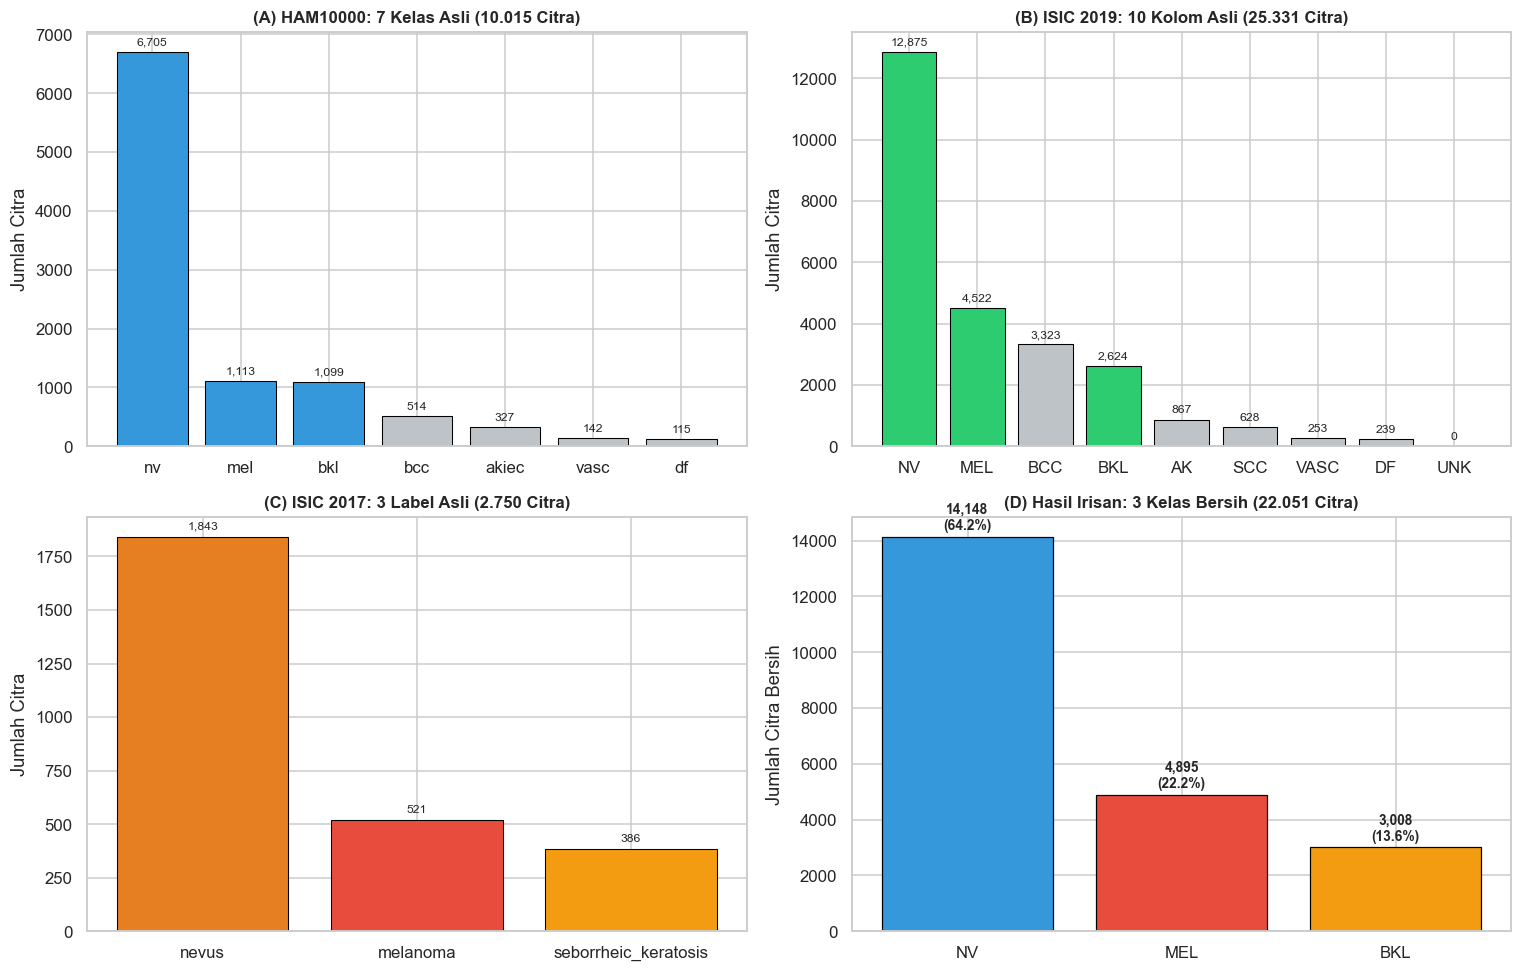

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. HAM10000: 7 Kelas Asli
colors_ham = ['#3498db' if x in ['nv', 'mel', 'bkl'] else '#bdc3c7' for x in df_ham_dx['Kode dx']]
axes[0, 0].bar(df_ham_dx['Kode dx'], df_ham_dx['Jumlah Gambar'], color=colors_ham, edgecolor='black', linewidth=0.7)
axes[0, 0].set_title('(A) HAM10000: 7 Kelas Asli (10.015 Citra)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Jumlah Citra')
for p in axes[0, 0].patches:
    h = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width()/2., h + 80, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 2. ISIC 2019: 10 Kolom Asli
colors_19 = ['#2ecc71' if x in ['NV', 'MEL', 'BKL'] else '#bdc3c7' for x in df_19_summary['Kolom']]
axes[0, 1].bar(df_19_summary['Kolom'], df_19_summary['Jumlah Gambar'], color=colors_19, edgecolor='black', linewidth=0.7)
axes[0, 1].set_title('(B) ISIC 2019: 10 Kolom Asli (25.331 Citra)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Jumlah Citra')
for p in axes[0, 1].patches:
    h = p.get_height()
    axes[0, 1].text(p.get_x() + p.get_width()/2., h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 3. ISIC 2017: 3 Label Asli
cnt_17 = df_17_all['label_asli'].value_counts()
axes[1, 0].bar(cnt_17.index, cnt_17.values, color=['#e67e22', '#e74c3c', '#f39c12'], edgecolor='black', linewidth=0.7)
axes[1, 0].set_title('(C) ISIC 2017: 3 Label Asli (2.750 Citra)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Jumlah Citra')
for p in axes[1, 0].patches:
    h = p.get_height()
    axes[1, 0].text(p.get_x() + p.get_width()/2., h + 25, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

# 4. Hasil Irisan: 3 Kelas Bersih
classes_final = ['NV', 'MEL', 'BKL']
counts_final  = [tot_nv, tot_mel, tot_bkl]
colors_final  = [COLOR_NV, COLOR_MEL, COLOR_BKL]
axes[1, 1].bar(classes_final, counts_final, color=colors_final, edgecolor='black', linewidth=0.8)
axes[1, 1].set_title('(D) Hasil Irisan: 3 Kelas Bersih (22.051 Citra)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Citra Bersih')
for p in axes[1, 1].patches:
    h = p.get_height()
    pct = h / sum(counts_final) * 100
    axes[1, 1].text(p.get_x() + p.get_width()/2., h + 150, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Langkah 10: Pemeriksaan Resolusi Citra dan Karakteristik Fisik
Mengecek dimensi piksel, aspek rasio, dan format kanal warna citra asli dari tiap folder dataset sebagai acuan standardisasi input model.

In [10]:
sample_records = []

def inspect_img(path, dataset_name):
    if os.path.exists(path):
        with Image.open(path) as img:
            w, h = img.size
            return {
                'Dataset': dataset_name,
                'File Contoh': os.path.basename(path),
                'Ukuran (Px)': f"{w} x {h}",
                'Rasio': round(w / h, 2),
                'Format': img.mode
            }
    return None

ham_sample = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_1', df_ham['image_id'].iloc[0] + '.jpg')
res_ham = inspect_img(ham_sample, 'HAM10000')
if res_ham: sample_records.append(res_ham)

isic19_folder = os.path.join(DATASET_DIR, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
sample19_files = [f for f in os.listdir(isic19_folder) if f.endswith('.jpg')]
if sample19_files:
    res_19 = inspect_img(os.path.join(isic19_folder, sample19_files[0]), 'ISIC 2019')
    if res_19: sample_records.append(res_19)

isic17_f = os.path.join(DATASET_DIR, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data')
sample17_files = [f for f in os.listdir(isic17_f) if f.endswith('.jpg')]
if sample17_files:
    res_17 = inspect_img(os.path.join(isic17_f, sample17_files[0]), 'ISIC 2017')
    if res_17: sample_records.append(res_17)

df_physical = pd.DataFrame(sample_records)
display(df_physical)

,Dataset,File Contoh,Ukuran (Px),Rasio,Format
0,HAM10000,ISIC_0027419.jpg,600 x 450,1.33,RGB
1,ISIC 2019,ISIC_0000000.jpg,1022 x 767,1.33,RGB
2,ISIC 2017,ISIC_0000000.jpg,1022 x 767,1.33,RGB


## Langkah 11: Pemeriksaan Visual Sampel Citra Nyata
Menampilkan contoh foto dermatologi fisik untuk masing-masing kelas target (NV, MEL, BKL).

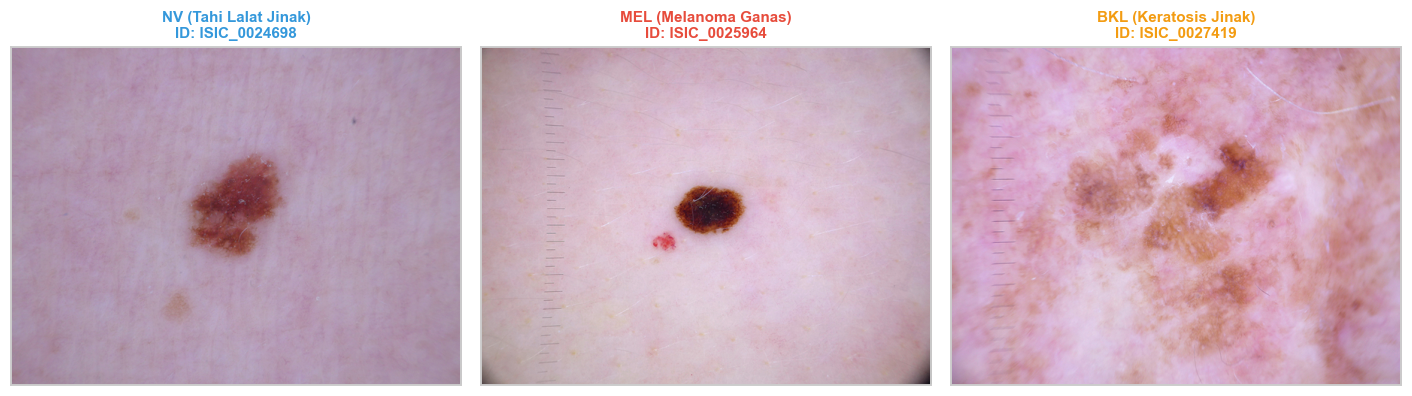

In [11]:
sample_nv_id  = df_ham[df_ham['dx'] == 'nv']['image_id'].iloc[0]
sample_mel_id = df_ham[df_ham['dx'] == 'mel']['image_id'].iloc[0]
sample_bkl_id = df_ham[df_ham['dx'] == 'bkl']['image_id'].iloc[0]

def find_ham_path(img_id):
    p1 = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_1', img_id + '.jpg')
    p2 = os.path.join(DATASET_DIR, 'HAM10K', 'HAM10000_images_part_2', img_id + '.jpg')
    return p1 if os.path.exists(p1) else p2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

samples = [
    (sample_nv_id, 'NV (Tahi Lalat Jinak)', COLOR_NV),
    (sample_mel_id, 'MEL (Melanoma Ganas)', COLOR_MEL),
    (sample_bkl_id, 'BKL (Keratosis Jinak)', COLOR_BKL)
]

for idx, (img_id, title, col) in enumerate(samples):
    img_p = find_ham_path(img_id)
    if os.path.exists(img_p):
        with Image.open(img_p) as im:
            axes[idx].imshow(im)
            axes[idx].set_title(f"{title}\nID: {img_id}", fontsize=10, fontweight='bold', color=col)
            axes[idx].grid(False)
            axes[idx].set_xticks([])
            axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

## Langkah 12: Kesimpulan Data Understanding dan Titik Lanjut
Rangkuman temuan kunci dari tahap Data Understanding:
1. **Validitas Ground Truth:** Seluruh 25.331 citra ISIC 2019 training memiliki label pasti pada 8 kelas medis (kolom UNK bernilai 0).
2. **Deduplikasi Data:** Seluruh 10.015 citra HAM10000 dipertahankan utuh, sedangkan 10.015 duplikat pada ISIC 2019 dan 720 duplikat pada ISIC 2017 berhasil dibersihkan.
3. **Harmonisasi Medis:** Penggabungan seborrheic keratosis ke BKL telah terjustifikasi kuat oleh literatur dermatologi internasional (Tschandl et al., 2018).
4. **Volume Dataset Bersih:** Diperoleh tepat 22.051 citra bersih untuk 3 kelas bersama (NV: 14.148 / 64,2%, MEL: 4.895 / 22,2%, BKL: 3.008 / 13,6%).
5. **Pencegahan Kebocoran:** Adanya 2.545 citra multi-sudut pada HAM10000 mewajibkan pembagian subset (train/val/test) dilakukan berbasis lesion_id (Lesion-Aware Split) pada notebook irisan_mapping.ipynb.